In [2]:
import numpy as np
from scipy.linalg import lu, solve_triangular
import matplotlib.pyplot as plt

In [3]:
# Parametri
c = 0.63  
b = 1500  
k = 0.6   
h = 2700  

# Variabili esogene
C_bar = 55  
I_bar = 75 
G_bar = 200
T_bar = 110 
M_bar = 200
P_bar = 1   

In [4]:
# Rappresentazione matriciale del modello: Ax = d
A = np.array([
    [1, -1, -1, 0],
    [-c, 1, 0, 0],
    [0, 0, 1, b],
    [k, 0, 0, -h]
])

d = np.array([G_bar, C_bar - c * T_bar, I_bar, M_bar / P_bar])

In [5]:
# Calcolo delle variabili endogene usando la fattorizzazione LU
P, L, U = lu(A)

In [6]:
# Risoluzione del sistema lineare
y = np.linalg.solve(L, P @ d) 
# in Matlab il pivoting viene applicato automaticamente, con scipy utilizziamo @ per effettuare la moltiplicazione tra la matrice di pivoting P e il vettore d
x = np.linalg.solve(U, y)

In [7]:
print("Risultati del modello IS-LM (economia chiusa):")
print(f"Prodotto (Y): {x[0]:.2f}")
print(f"Consumo (C): {x[1]:.2f}")
print(f"Investimento (I): {x[2]:.2f}")
print(f"Tasso di interesse (R): {x[3]:.2%}")

Risultati del modello IS-LM (economia chiusa):
Prodotto (Y): 528.64
Consumo (C): 318.74
Investimento (I): 9.90
Tasso di interesse (R): 4.34%


In [8]:
# Valori di equilibrio
Y_eq = x[0]
R_eq = x[3]

# Intervallo per Y attorno al valore di equilibrio
Y_values = np.linspace(0.95 * Y_eq, 1.05 * Y_eq, 100)

# Calcolo della curva IS: I = Y - C - G e I = I_bar - bR
C_values = C_bar + c * (Y_values - T_bar)
I_values = Y_values - C_values - G_bar
IS_values = (I_bar - I_values) / b

# Calcolo della curva LM: M_bar / P_bar = kY - hR risolta per R
LM_values = (k * Y_values - M_bar / P_bar) / h

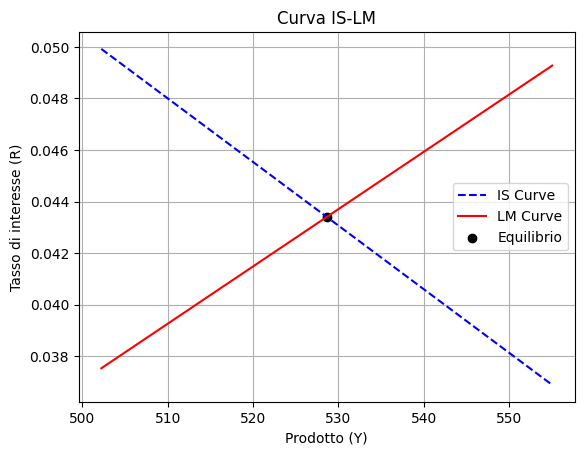

In [9]:
# Plot delle curve IS e LM
plt.plot(Y_values, IS_values, label="IS Curve", color="blue", linestyle="--")
plt.plot(Y_values, LM_values, label="LM Curve", color="red")
plt.scatter(Y_eq, R_eq, color="black", marker="o", label="Equilibrio")

# Titoli e etichette
plt.title("Curva IS-LM")
plt.xlabel("Prodotto (Y)")
plt.ylabel("Tasso di interesse (R)")
plt.legend()
plt.grid()
plt.show()